### Assignment 3

#### Statement of use of AI
In Task 0, I used it for some guidance in setting up Ollama. In task 1, I used it to help me debug the problems I was having. In task 2, I used it where required in part c. In task 3, I used it to decide the best graphs to use in the EDA.


#### Task 0

In [66]:
# Part a 

# Set up ollama using commander prompt and the following is connecting to it using Ollama's API
import requests
import json

url = "http://localhost:11434/api/chat"

data = {
    "model": "gemma3:270m",
    "messages": [
        {
            "role": "user",
            "content": "Hello!"
        }
    ],
    "stream": False 
}

response = requests.post(url, json=data)

print(response.json()["message"]["content"])

Hello! How can I help you today?



In [67]:
# Part b
# In command prompt I loaded the 270m parameter verison.
url = "http://localhost:11434/api/chat"

data = {
    "model": "gemma3:270m",
    "messages": [
        {
            "role": "user",
            "content": "How many countires do pigeons live in?"
        }
    ],
    "stream": False 
}

response = requests.post(url, json=data)

print(response.json()["message"]["content"])

Pigeons live in a relatively small number of colonies, typically around 100-200.


In [68]:
# Part C
url = "http://localhost:11434/api/chat"

data = {
    "model": "gemma3:1b",
    "messages": [
        {
            "role": "user",
            "content": "Can penguins fly?"
        }
    ],
    "stream": False 
}

response = requests.post(url, json=data)

print(response.json()["message"]["content"])

No, penguins cannot fly. Despite their waddling gait and adorable appearance, they are flightless birds! 

They've evolved over millions of years to be incredibly well-suited for swimming and diving in the cold, icy waters of the Southern Hemisphere. 

Here's a breakdown of why they can't fly:

* **Wings:** Penguins have wings, but they're adapted for swimming, not flying. Their wings are shaped like flippers, perfect for propelling them through the water.
* **Weight and Body Structure:** They are heavy and have a compact body shape, making it difficult to generate the lift needed for flight.
* **Bone Structure:** Their bones are lightweight and hollow, crucial for buoyancy in the water.

**However, they *do* have some amazing adaptations for swimming:**

* **Powerful Flippers:** Their flippers are incredibly strong and maneuverable, allowing them to swim with exceptional speed and agility.
* **Dense Bones:** Their bones are dense and lightweight.

Do you have any other questions about

#### Task 1

In [1]:
# Part a
# Creating the function

Model_name = "gemma3:270m"

def classify_email(headline):
    url = "http://localhost:11434/api/generate"

    response = requests.post(
        url,
        json={
            "model": Model_name,
            "prompt": f"""
Classify the email headline into one of the following categories:
- spam
- work
- unknown

Respond with only one word. Do not explain. It must be one of the above categories. Only respond with either spam, work or unknown, do not respond with anything else.

Headline: {headline}
""",
            "stream": False 
         }
    )

    return response.json()["response"].strip().lower()


In [75]:
# Part b
with open("C:/Users/maisy/emails.csv", "r", encoding="utf-8") as f:
    headlines = f.read().splitlines()[1:]

for email in headlines:
    result = classify_email(email)
    print(result)

unknown
work
unknown
unknown
unknown
unknown
work
unknown
unknown
work
work
unknown


In [76]:
# Part c
Model_name= "gemma3:1b"

with open("C:/Users/maisy/emails.csv", "r", encoding="utf-8") as f:
    headlines = f.read().splitlines()[1:]

for email in headlines:
    result = classify_email(email)
    print(result)


spam
spam
spam
work
work
work
work
work
unknown
unknown
unknown
unknown


Comment: The 720m model has more unknowns with 8, compared to just 4 on the 1b version. The 720m version didn't recognise any as spam whereas the 1b version recognised 3 as spam. The recongised a similar amount as work, however the ones they recognised as work where different. They recognised a few the same but mostly different.

In [79]:
# Part c
import pandas as pd

# Running the models 3 times
results_270m = []
results_1b = []

for i in range(3):
    run_270m = []
    run_1b = []
   
    for email in headlines:
        Model_name = "gemma3:270m"
        run_270m.append(classify_email(email))

        Model_name = "gemma3:1b"
        run_1b.append(classify_email(email))

    results_270m.append(run_270m)
    results_1b.append(run_1b)

# Load into dataframe

df=pd.DataFrame({
    "headline": headlines,

    "270m_run1" : results_270m[0],
    "270m_run2" : results_270m[1],
    "270m_run3" : results_270m[2],

    "1b_run1": results_1b[0],
    "1b_run2": results_1b[1],
    "1b_run3": results_1b[2],
})

display(df)

,headline,270m_run1,270m_run2,270m_run3,1b_run1,1b_run2,1b_run3
0,URGENT: Your account will be suspended within ...,unknown,work,unknown,spam,spam,spam
1,Congratulations! You have won a 1000€ gift car...,work,spam,work,spam,spam,spam
2,Hot singles in your area are waiting to meet y...,unknown,work,unknown,spam,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,unknown,work,unknown,work,work,work
4,Meeting agenda for Thursday's project review,unknown,work,work,work,work,work
5,"Q3 budget report attached, please review by Fr...",unknown,unknown,unknown,work,work,work
6,Reminder: Annual performance review scheduled ...,work,work,work,work,work,work
7,"Updated draft of the manuscript, comments welcome",work,unknown,work,work,work,work
8,Quick question about last week,unknown,unknown,unknown,unknown,unknown,unknown
9,Following up,unknown,unknown,unknown,unknown,unknown,unknown


##### Part d
Comment: In the 1b version, only 1 categorisation changed in the three attempts in run 2, however it was changed back to unknown in run 3. However, in 270m version, there was a lot more changes over the three runs. This happened because smaller language models (270m) are less consistent and have a weaker understanding of context. Larger language models (1b) have more parameters and therefore usually produce more stable and accurate classifications.

Task 2

In [80]:
# Part a
import json

def classify_news(headline):
    url = "http://localhost:11434/api/generate"

    model_name = "gemma3:1b"   # used 1b as 4b was too slow
    response = requests.post(
        url,
        json={
            "model": model_name,
            "prompt": f"""

Classify the following financial news headlines.

Choose one topic from:
- earnings
- mergers
- regulation
- macroeconomics

Respond with only one word. Do not explain. It must be one of the above categories. Only respond with either earnings, mergers, regulation, macroeconomics, do not respond with anything else.

Choose one sentiment from: 
- positive
- negative
- neutral

Respond with only one word. Do not explain. It must be one of the above categories. Only respond with either positive, negative, netural, do not respond with anything else.

Return the result only in valid JSON format like this:
{{"topic":"earnings", "sentiment": "positive"}}

Headline: {headline}
""",
            "stream": False 
         }
    )

    result = response.json()["response"].strip()
    return json.loads(result)
    

In [83]:
# Part b

import pandas as pd

# Loading the dataset
with open("C:/Users/maisy/news.csv", "r", encoding="utf-8") as f:
    headlines = f.read().splitlines()[1:]

topics = []
sentiments = []

# Classifying the headlines
for headline in headlines:
    result = classify_news(headline)

    topics.append(result["topic"])
    sentiments.append(result["sentiment"])

# Add the results to a dataframe
df = pd.DataFrame({
    "headline": headlines,
    "topic": topics,
    "sentiment": sentiments
})

display(df)

,headline,topic,sentiment
0,Nordion Industries beats Q1 earnings estimates...,earnings,positive
1,Helvora Pharmaceuticals misses earnings foreca...,earnings,negative
2,"Aurelis Bank reports steady quarterly profit, ...",earnings,positive
3,Veridyne Logistics to acquire rival Trantec in...,mergers,positive
4,Antitrust regulators block proposed merger bet...,regulation,negative
5,Kestrel Semiconductor confirms early-stage mer...,mergers,positive
6,New EU AI Act compliance rules expected to rai...,regulation,negative
7,Finnish FSA grants Norvik Capital expanded lic...,mergers,positive
8,"Eurozone inflation cools to 2.1%, easing press...",earnings,positive
9,Rising interest rates weigh on Tessaro Real Es...,macroeconomics,negative


##### Part c

I gave Claude the dataset and the prompt and these are the results:

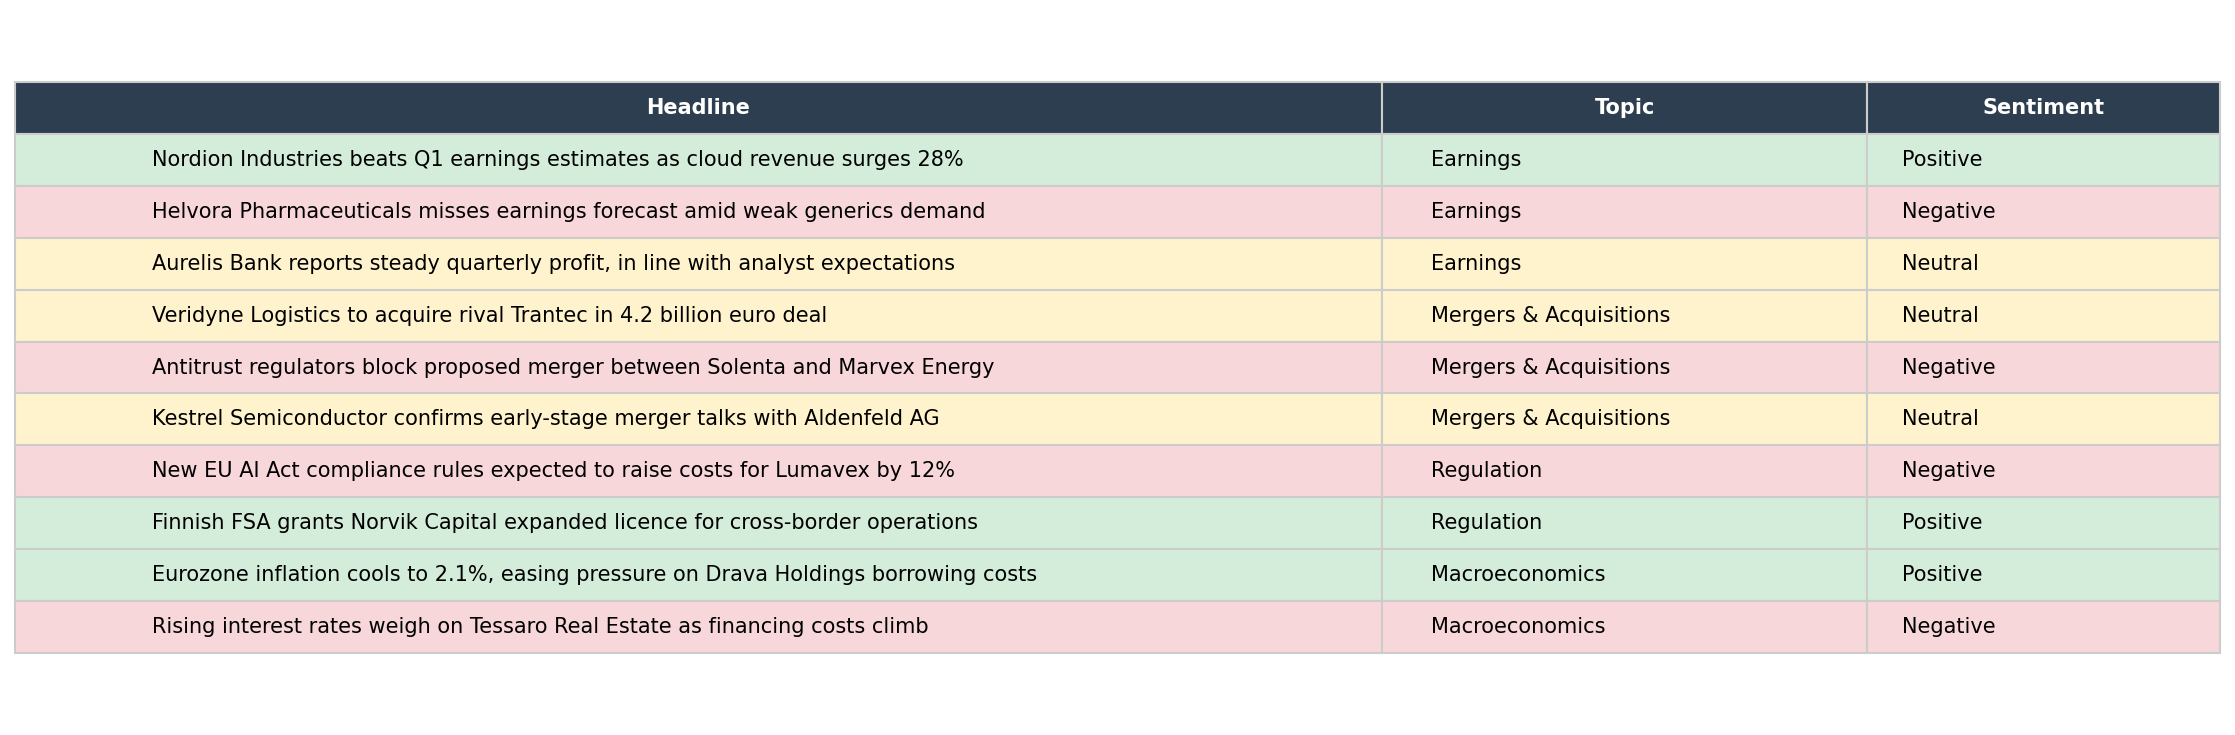

###### Comparison
For topic, they classified seven the same but three different. When they disagreed, I believe Claude to have accurately classified them while ollama did not. For example in the headline begining antitrust, I believe it to be about mergers, which Claude identified however, ollama classified it as regualtion. For sentiment, ollama never described it as netural, whereas Claude did 3 times, in these instances, I beleive them to be netural. In terms of positive and negative, they classifed it the same. Claude seemed to have more nuance describing some as neutral whereas ollama described them as just positive or negative. Overall, Claude is more accurate and this is because it is a larger and more heavily trained model meaning it can follow instructions more reliably and handle ambiugity and sentiment analysis more consistently.

#### Task 3

##### Part a

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("C:/Users/maisy/bank-additional.csv", sep=";")

In [5]:
#Inspecting the data
df.columns
df.info()
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [6]:
# Looking at the shape 
df.shape

(4119, 21)

In [7]:
# Summary statistics
display(df.describe())
display(df.describe(include='object'))

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,1012,2509,1264,3315,2175,3349,2652,1378,860,3523,3668


In [8]:
# Checking for missing values
display(df.isnull().sum())

for col in df.columns:
    print(col, (df[col] == 'unknown').sum())

  

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

age 0
job 39
marital 11
education 167
default 803
housing 105
loan 105
contact 0
month 0
day_of_week 0
duration 0
campaign 0
pdays 0
previous 0
poutcome 0
emp.var.rate 0
cons.price.idx 0
cons.conf.idx 0
euribor3m 0
nr.employed 0
y 0


In [9]:
# Checking how many unique values in each column 
df.nunique()

age                67
job                12
marital             4
education           8
default             3
housing             3
loan                3
contact             2
month              10
day_of_week         5
duration          828
campaign           25
pdays              21
previous            7
poutcome            3
emp.var.rate       10
cons.price.idx     26
cons.conf.idx      26
euribor3m         234
nr.employed        11
y                   2
dtype: int64

In [10]:
# Checking how many types of job there are
df["job"].value_counts()

# could do this for all columns replacing job with each column name, but takes up a lot of space and is not easy to read

job
admin.           1012
blue-collar       884
technician        691
services          393
management        324
retired           166
self-employed     159
entrepreneur      148
unemployed        111
housemaid         110
student            82
unknown            39
Name: count, dtype: int64

#### Visualising the data

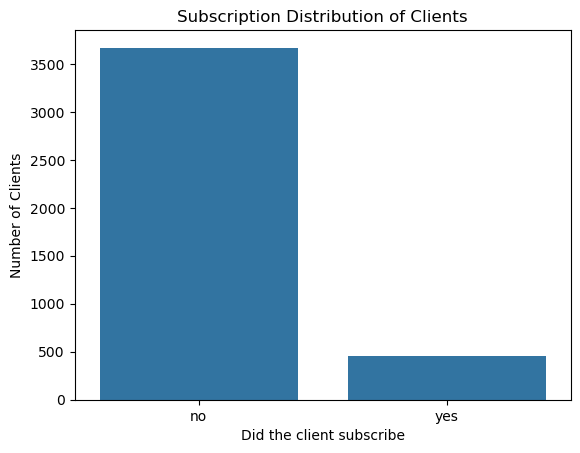

In [11]:
# Visualising the target distribution
sns.countplot(x="y", data=df)
plt.title("Subscription Distribution of Clients")
plt.xlabel("Did the client subscribe")
plt.ylabel("Number of Clients")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

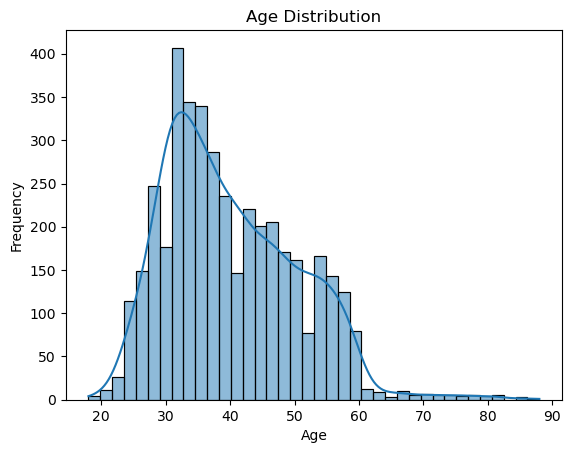

In [12]:
# Histogram of age
sns.histplot(data = df, x = "age", kde = True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

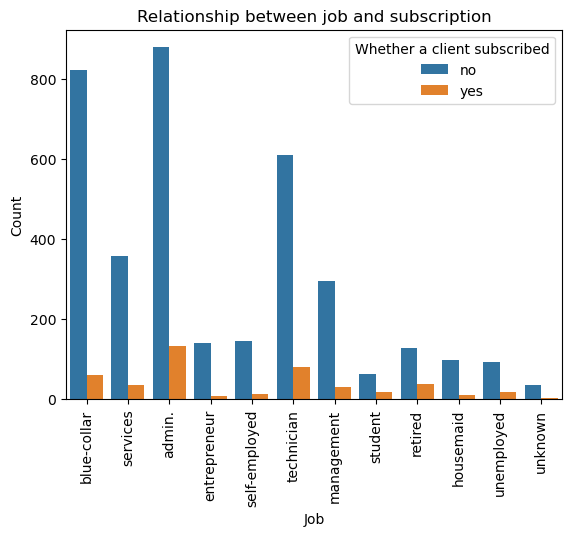

In [13]:
# Barplot of job vs subscription
sns.countplot(x="job", hue="y", data=df)
plt.title("Relationship between job and subscription")
plt.xlabel("Job")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.legend(title="Whether a client subscribed")
plt.show

The exploratory data analysis provided a clear understanding of the dataset structure with 4119 rows and 21 columns with 3 different data types: object, float and integer. There are no missing values but there are unkown values in six columns. From the visualisations we can begin to see that the proportion of clients that didn't subscribe is much higher. We can see that the distribution of ages is from around 20 to 90 with a peak in 30-40 range. We can also see that some jobs have much higher subscription count than others.  

##### Part b

In [22]:
# Using one hot encoding to convert text fields to numeric form
df_encoded = pd.get_dummies(df)

Looking at what variables could be unnecessary I thought of the what the later model is trying to predict which is based on certain varibles will a person subscribe a term deposit. Other than duration of the call, a banker could find out the information and use it to increase the chance of a person subscribing. However, with last contact duration, a person can't know what this will be and it is therefore not useful in predicting whether a person will subscribe a term deposit and will be removed.

In [28]:
df_encoded.drop("duration", axis=1)

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_admin.,...,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,y_no,y_yes
0,-0.980752,-0.209228,0.201031,-0.351356,-1.206054,-1.185448,-1.240939,-1.331707,-0.914779,False,...,True,False,False,False,False,False,True,False,True,False
1,-0.107991,0.569634,0.201031,-0.351356,0.649441,0.715193,0.892269,0.711698,0.332862,False,...,True,False,False,False,False,False,True,False,True,False
2,-1.465619,-0.598660,0.201031,-0.351356,0.841389,1.528273,-0.283172,0.773427,0.836535,False,...,False,False,False,False,True,False,True,False,True,False
3,-0.204965,0.180203,0.201031,-0.351356,0.841389,1.528273,-0.283172,0.771697,0.836535,False,...,True,False,False,False,False,False,True,False,True,False
4,0.667795,-0.598660,0.201031,-0.351356,-0.118350,-0.655478,-0.326707,0.328632,0.398028,True,...,False,True,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4114,-0.980752,-0.598660,0.201031,-0.351356,0.841389,0.583995,-0.479079,0.771120,0.836535,True,...,False,False,True,False,False,False,True,False,True,False
4115,-0.107991,-0.598660,0.201031,-0.351356,0.841389,0.583995,-0.479079,0.771697,0.836535,True,...,True,False,False,False,False,False,True,False,True,False
4116,-1.271672,-0.209228,0.201031,1.494607,-1.206054,-1.185448,-1.240939,-1.308054,-0.914779,False,...,False,True,False,False,False,True,False,False,True,False
4117,1.734503,-0.598660,0.201031,-0.351356,0.841389,-0.234264,0.957571,0.775735,0.836535,True,...,True,False,False,False,False,False,True,False,True,False


In [29]:
# Scaling all the numerical columns not the ones categorical ones
from sklearn.preprocessing import StandardScaler

num_cols= ["age", "duration", "campaign", "pdays", "previous", "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]

scaler= StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

##### Part c

This is a classification task as we are trying to predict whether customers will subscribe based on various factors. The label of whether they subscribe or not is a discrete categorical label, therefore making it a classification task.

The machine learning algorithms chosen are Naive Bayes, K-nearest neighbour and random forest.

Naive Bayes has been chosen as it is a fast and simple probabilistic classifier that is easily interpretable.

K-nearest neighbours has been chosen as it classifies new data points based on the similarity of nearby data points and is easy to interpret and implement.

Random forest has been chosen as the simplicity of the underlying decision trees makes the model efficient, while aggregation of multiple trees improves accuracy. 

In [33]:
# Importing the machine learnign tools
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Preparing features and target variable0.25
x = df_encoded.drop(["y_yes", "y_no"], axis=1)
y= df_encoded["y_yes"]

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.25) 

###### Naive Bayes Model

In [39]:
nb_model = GaussianNB() # creating the model

nb_model.fit(x_train, y_train) # training the model

nb_predictions = nb_model.predict(x_test) # making predicitions

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_predictions))

Naive Bayes Accuracy: 0.5495145631067961


As Naive Bayes has very few hyperparameters paramters, no tuning is needed as it is typically used with default settings.

###### K-nearest Neighbors Model

In [43]:
knn = KNeighborsClassifier(n_neighbors=5) # creating the model

knn.fit(x_train, y_train) # training the model

y_pred = knn.predict(x_test) # making predicitions

print("K-nearest neighbors Accuracy:", accuracy_score(y_test, y_pred))

K-nearest neighbors Accuracy: 0.903883495145631


In [46]:
# Hyperparameter tuning 
for k in [3, 5, 7, 9, 11]:

    knn = KNeighborsClassifier(n_neighbors=5) 
    knn.fit(x_train, y_train) 

    y_pred = knn.predict(x_test) 

    print("k=", k, "Accuracy:", accuracy_score(y_test, y_pred))

k= 3 Accuracy: 0.903883495145631
k= 5 Accuracy: 0.903883495145631
k= 7 Accuracy: 0.903883495145631
k= 9 Accuracy: 0.903883495145631
k= 11 Accuracy: 0.903883495145631


###### Random Forest Model

In [47]:
rfm = RandomForestClassifier(n_estimators=100, random_state=42) # Creating the model

rfm.fit(x_train, y_train) # training the model

rfm_pred = rfm.predict(x_test) # making predicitions

print("Random Forest Accuracy:", accuracy_score(y_test, rfm_pred))

Random Forest Accuracy: 0.9097087378640777


In [48]:
# Tuning hyperparameters: n_estimators

for trees in [50, 100, 300, 500]:
    rfm = RandomForestClassifier(n_estimators=trees, random_state=42)

    rfm.fit(x_train, y_train) 
    
    rfm_pred = rfm.predict(x_test)

    print("n_estimators = ", trees, "Accuracy:", accuracy_score(y_test, rfm_pred))

n_estimators =  50 Accuracy: 0.9009708737864077
n_estimators =  100 Accuracy: 0.9097087378640777
n_estimators =  300 Accuracy: 0.9067961165048544
n_estimators =  500 Accuracy: 0.9048543689320389


In [49]:
# Tuning hyperparameters: depth

for depth in [5, 10, 15, None]:
    rfm = RandomForestClassifier(n_estimators=trees, max_depth=depth, random_state=42)

    rfm.fit(x_train, y_train) 
    
    rfm_pred = rfm.predict(x_test)

    print("max_depth = ", depth, "Accuracy:", accuracy_score(y_test, rfm_pred))

max_depth =  5 Accuracy: 0.9048543689320389
max_depth =  10 Accuracy: 0.9048543689320389
max_depth =  15 Accuracy: 0.9048543689320389
max_depth =  None Accuracy: 0.9048543689320389


##### Part d

In [50]:
# importing cross_validation
from sklearn.model_selection import cross_val_score

In [ ]:
# Naive Bayes Cross Validation
